# 1. Import Raw Dataset

In [1]:
try:
    from google.colab import drive  # Colab only
except Exception:
    drive = None
import os as _os
if drive is not None and not _os.path.ismount("/content/drive"):
    drive.mount("/content/drive")  # [sanitized] optional; data paths are relative to DrugReview_ROOT

Mounted at /content/drive


In [ ]:
import pandas as pd

train_raw = pd.read_csv("./data/drugsComTrain_raw.csv")
test_raw  = pd.read_csv("./data/drugsComTest_raw.csv")

df_drugs = pd.concat([train_raw, test_raw], ignore_index=True)



In [ ]:
print(df_drugs.shape)
df_drugs.head()

(215063, 8)


,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment_5
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27,very_positive
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,positive
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,neutral
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10,positive
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,very_positive


In [ ]:
# Optional: drop exact duplicate rows if any
df_drugs = df_drugs.drop_duplicates(subset=["uniqueID"])  # or ["drugName","condition","review","rating"]
print(df_drugs.shape)
df_drugs.head()

(215063, 8)


,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment_5
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27,very_positive
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,positive
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,neutral
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10,positive
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,very_positive


In [ ]:
def rating_to_sentiment(r):
    if r <= 2:  return "very_negative"
    if r <= 4:  return "negative"
    if r <= 6:  return "neutral"
    if r <= 8:  return "positive"
    return "very_positive"

df_drugs["sentiment_5"] = df_drugs["rating"].apply(rating_to_sentiment)

In [ ]:
# --- 1. Project & Experiment Paths ---

import sys
from pathlib import Path

DrugReview_ROOT = Path(".")
SRC = DrugReview_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

TEXT_COLUMN = "review"
LABEL_COLUMN = "sentiment_5"
LABEL_COLUMN_ENCODED = "sentiment_Encoded"

In [ ]:
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 32
N_ITERATIONS = 10
RANDOM_STATE = 42

In [ ]:
# === ML SECTION SETUP =====================================================
# Put this cell at the BEGINNING of your ML section, AFTER the WORKDIR block.

import importlib
from pathlib import Path
import joblib
import json
import numpy as np


# -------------------------------------------------------------------------
# 1. Reload all ML-related modules
# -------------------------------------------------------------------------
import DrugReview_nlp.ml_logreg as ml_logreg
import DrugReview_nlp.ml_svm as ml_svm
import DrugReview_nlp.ml_rf as ml_rf
import DrugReview_nlp.ml_lgbm as ml_lgbm
import DrugReview_nlp.ml_eval as ml_eval
import DrugReview_nlp.ml_interpret as ml_interpret

importlib.reload(ml_logreg)
importlib.reload(ml_svm)
importlib.reload(ml_rf)
importlib.reload(ml_lgbm)
importlib.reload(ml_eval)
importlib.reload(ml_interpret)

# -------------------------------------------------------------------------
# 2. Import the functions you will call in the ML section
# -------------------------------------------------------------------------

# --- Logistic Regression ---
from DrugReview_nlp.ml_logreg import (
    train_logreg_text_extra,   # text + extra features
    predict_logreg,
)

# --- SVM ---
from DrugReview_nlp.ml_svm import (
    train_svm_text_extra,      # text + extra features
    predict_svm,
)

# --- Random Forest ---
from DrugReview_nlp.ml_rf import (
    train_rf_text_extra,       # text + extra features
    predict_rf,
)

# --- LightGBM ---
from DrugReview_nlp.ml_lgbm import (
    train_lgbm_text_extra,     # text + extra features
    predict_lgbm,
)

# --- Evaluation helpers ---
from DrugReview_nlp.ml_eval import (
    evaluate_ml_model,
    evaluate_ml_multiclass,
    evaluate_ML_multiclass_with_extra,
    plot_confusion_matrix,
    plot_multiclass_roc,
    bootstrap_f1_ci,               # NEW
    bootstrap_auc_ci_multiclass,   # NEW
)

# --- Interpretation helpers ---
from DrugReview_nlp.ml_interpret import (
    linear_model_global_importance,      # LogReg coefficients → abs, 0–100
    plot_linear_importance_barh,         # mako barh for linear models
    compute_tree_feature_importance,     # RF/LGBM feature_importances_
    plot_feature_importance_pretty,      # mako barh for any importance df
    compute_permutation_feature_importance,  # SVM permutation importance
)

# -------------------------------------------------------------------------
# 3. Shared ML config
# -------------------------------------------------------------------------

# Use the same seed everywhere
ML_RANDOM_STATE = RANDOM_STATE  # assuming RANDOM_STATE is already defined

# If you want to override internal param grids, define them here.
# If left as None, each train_* will use its own default grid.
LOGREG_PARAM_GRID = None
SVM_PARAM_GRID    = None
RF_PARAM_GRID     = None
LGBM_PARAM_GRID   = None


In [ ]:
import importlib
import DrugReview_nlp.data_prep as data_prep

importlib.reload(data_prep)

from DrugReview_nlp.data_prep import build_clean_dataset, split_train_val_test_grouped

# Clean text + encode labels + (optionally) build ai_* features
df_clean, label_encoder = build_clean_dataset(
    df_drugs,
    text_col=TEXT_COLUMN,
    label_col=LABEL_COLUMN,
    label_col_encoded=LABEL_COLUMN_ENCODED,
)

print("Cleaned data shape:", df_clean.shape)
df_clean.head()

Cleaned data shape: (215063, 9)


,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment_5,sentiment_Encoded
0,206461,Valsartan,Left Ventricular Dysfunction,it has no side effect i take it in combination...,9,20-May-12,27,very_positive,4
1,95260,Guanfacine,ADHD,my son is halfway through his fourth week of i...,8,27-Apr-10,192,positive,2
2,92703,Lybrel,Birth Control,i used to take another oral contraceptive whic...,5,14-Dec-09,17,neutral,1
3,138000,Ortho Evra,Birth Control,this is my first time using any form of birth ...,8,3-Nov-15,10,positive,2
4,35696,Buprenorphine / naloxone,Opiate Dependence,suboxone has completely turned my life around ...,9,27-Nov-16,37,very_positive,4


In [ ]:
# Make id a proper column for grouping
df_clean = df_clean.reset_index(drop=False).rename(columns={"uniqueID": "group_id"})

from DrugReview_nlp.data_prep import split_train_val_test_grouped


# 0) clean obvious garbage "conditions"
bad_pat = r"users found this comment helpful"
df_clean = df_clean[
    df_clean["condition"].notna()
    & ~df_clean["condition"].str.contains(bad_pat, case=False, na=False)
    & (df_clean["condition"].str.strip().str.lower() != "nan")
].copy()

# 1) tiers (exact names from your list)
tier1 = {
    # HTN
    "High Blood Pressure", "Hypertensive Emergency",
    # Lipids
    "High Cholesterol",
    "High Cholesterol, Familial Heterozygous",
    "High Cholesterol, Familial Homozygous",
    "Hypertriglyceridemia",
    "Hyperlipoproteinemia",
    "Hyperlipoproteinemia Type IIa, Elevated LDL",
    "Hyperlipoproteinemia Type IV, Elevated VLDL",
    "Hyperlipoproteinemia Type III, Elevated beta-VLDL   IDL",
    # Diabetes
    "Diabetes, Type 2", "Diabetes, Type 1", "Gestational Diabetes",
}

tier2_add = {
    "Obesity",
    "Insulin Resistance Syndrome",
    "Nonalcoholic Fatty Liver Disease",
    "Obstructive Sleep Apnea/Hypopnea Syndrome",
    # optional complications (keep if you want)
    "Diabetic Kidney Disease",
    "Diabetic Peripheral Neuropathy",
    "Diabetic Macular Edema",
}

tier2 = tier1 | tier2_add

# 2) subset
df_sangao_t1 = df_clean[df_clean["condition"].isin(tier1)]
df_sangao_t2 = df_clean[df_clean["condition"].isin(tier2)]

# 3) quick sanity counts
print("Tier1 n =", len(df_sangao_t1))
print("Tier2 n =", len(df_sangao_t2))
print("\nTop Tier1 conditions:\n", df_sangao_t1["condition"].value_counts().head(20))
print("\nTop Tier2 conditions:\n", df_sangao_t2["condition"].value_counts().head(20))

df_train, df_val, df_test, df_all = split_train_val_test_grouped(
    df_sangao_t2,
    group_col="group_id",
    label_col_encoded=LABEL_COLUMN_ENCODED,
    test_size=0.20,
    val_size_of_train=0.25,
    random_state=RANDOM_STATE,
)

for name, df_ in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(name, df_.shape)

# ---------- NEW: keep a df_clean WITH split, and save it ----------
# df_all is the full dataframe returned by the function, with 'split' already set
df_clean = df_all.copy()


Tier1 n = 7715
Tier2 n = 12883

Top Tier1 conditions:
 condition
Diabetes, Type 2                                           3362
High Blood Pressure                                        3104
High Cholesterol                                            817
Diabetes, Type 1                                            185
Hypertriglyceridemia                                         99
High Cholesterol, Familial Heterozygous                      80
High Cholesterol, Familial Homozygous                        17
Hyperlipoproteinemia Type IIa, Elevated LDL                  17
Hyperlipoproteinemia                                         16
Hypertensive Emergency                                       14
Hyperlipoproteinemia Type IV, Elevated VLDL                   2
Hyperlipoproteinemia Type III, Elevated beta-VLDL   IDL       1
Gestational Diabetes                                          1
Name: count, dtype: int64

Top Tier2 conditions:
 condition
Obesity                                    

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Raw texts from each split
X_train_text_raw = df_train[TEXT_COLUMN].tolist()
X_val_text_raw   = df_val[TEXT_COLUMN].tolist()
X_test_text_raw  = df_test[TEXT_COLUMN].tolist()

tfidf = TfidfVectorizer(
    max_features=VOCAB_SIZE,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train_text_raw)
X_val_tfidf   = tfidf.transform(X_val_text_raw)
X_test_tfidf  = tfidf.transform(X_test_text_raw)

# Labels
y_train_ml = df_train[LABEL_COLUMN_ENCODED].values
y_val_ml   = df_val[LABEL_COLUMN_ENCODED].values
y_test_ml  = df_test[LABEL_COLUMN_ENCODED].values

print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

TF-IDF shapes: (7729, 10000) (2577, 10000) (2577, 10000)


In [ ]:
# === ML SECTION SETUP =====================================================
# Put this cell at the BEGINNING of your ML section, AFTER the WORKDIR block.

import importlib
from pathlib import Path
import joblib
import json
import numpy as np


# -------------------------------------------------------------------------
# 1. Reload all ML-related modules
# -------------------------------------------------------------------------
import DrugReview_nlp.ml_logreg as ml_logreg
import DrugReview_nlp.ml_svm as ml_svm
import DrugReview_nlp.ml_rf as ml_rf
import DrugReview_nlp.ml_lgbm as ml_lgbm
import DrugReview_nlp.ml_eval as ml_eval
import DrugReview_nlp.ml_interpret as ml_interpret

importlib.reload(ml_logreg)
importlib.reload(ml_svm)
importlib.reload(ml_rf)
importlib.reload(ml_lgbm)
importlib.reload(ml_eval)
importlib.reload(ml_interpret)

# -------------------------------------------------------------------------
# 2. Import the functions you will call in the ML section
# -------------------------------------------------------------------------

# --- Logistic Regression ---
from DrugReview_nlp.ml_logreg import (
    train_logreg_text_extra,   # text + extra features
    predict_logreg,
)

# --- SVM ---
from DrugReview_nlp.ml_svm import (
    train_svm_text_extra,      # text + extra features
    predict_svm,
)

# --- Random Forest ---
from DrugReview_nlp.ml_rf import (
    train_rf_text_extra,       # text + extra features
    predict_rf,
)

# --- LightGBM ---
from DrugReview_nlp.ml_lgbm import (
    train_lgbm_text_extra,     # text + extra features
    predict_lgbm,
)

# --- Evaluation helpers ---
from DrugReview_nlp.ml_eval import (
    evaluate_ml_model,
    evaluate_ml_multiclass,
    evaluate_ML_multiclass_with_extra,
    plot_confusion_matrix,
    plot_multiclass_roc,
    bootstrap_f1_ci,               # NEW
    bootstrap_auc_ci_multiclass,   # NEW
)

# --- Interpretation helpers ---
from DrugReview_nlp.ml_interpret import (
    linear_model_global_importance,      # LogReg coefficients → abs, 0–100
    plot_linear_importance_barh,         # mako barh for linear models
    compute_tree_feature_importance,     # RF/LGBM feature_importances_
    plot_feature_importance_pretty,      # mako barh for any importance df
    compute_permutation_feature_importance,  # SVM permutation importance
)

# -------------------------------------------------------------------------
# 3. Shared ML config
# -------------------------------------------------------------------------

# Use the same seed everywhere
ML_RANDOM_STATE = RANDOM_STATE  # assuming RANDOM_STATE is already defined

# If you want to override internal param grids, define them here.
# If left as None, each train_* will use its own default grid.
LOGREG_PARAM_GRID = None
SVM_PARAM_GRID    = None
RF_PARAM_GRID     = None
LGBM_PARAM_GRID   = None


In [ ]:

# -*- coding: utf-8 -*-
"""ml_logreg.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/16JAmHOKOTWCERk2qEetfD8sqSqfkC93x
"""

from __future__ import annotations

import itertools
import time
from typing import Any, Dict, Optional, Sequence, Tuple

import numpy as np
from scipy.sparse import hstack, csr_matrix, issparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


# -------------------------------------------------------------------
# 0. Internal helper: combine text + extra features
# -------------------------------------------------------------------

def _build_augmented_matrix(X_text, X_extra):
    """
    Combine TF-IDF text features with extra numeric features.
    If X_extra is None, returns X_text as-is.
    """
    if X_extra is None:
        return X_text

    if not issparse(X_text):
        raise ValueError("X_text should be a sparse matrix (e.g., TF-IDF).")

    # Convert dense extras to sparse if needed
    if X_extra is not None and not issparse(X_extra):
        X_extra = csr_matrix(X_extra)

    return hstack([X_text, X_extra])


# -------------------------------------------------------------------
# 1. Core trainer (feature-agnostic)
# -------------------------------------------------------------------

def train_logreg(
    X_train_text,
    y_train: Sequence[int],
    X_val_text,
    y_val: Sequence[int],
    X_train_extra=None,
    X_val_extra=None,
    param_grid: Optional[Dict[str, Sequence[Any]]] = None,
    random_state: int = 42,
    verbose: bool = True,
) -> Tuple[LogisticRegression, Dict[str, Any], float]:
    """
    Core Logistic Regression training with manual grid search.

    - Works with:
        * text-only:   pass X_*_extra=None
        * text+extra:  pass extra arrays/matrices
    - Uses weighted F1 on the validation set to pick the best model.

    Parameters
    ----------
    X_train_text, X_val_text : sparse matrices (TF-IDF)
    X_train_extra, X_val_extra : np.ndarray or sparse matrices (or None)
    y_train, y_val : label arrays
    param_grid : dict of hyperparameters -> list of values
    random_state : for LR reproducibility
    verbose : print progress and results

    Returns
    -------
    best_model : fitted LogisticRegression
    best_params : dict of best hyperparameters
    best_f1 : best validation F1 (weighted)
    """
    if param_grid is None:
        param_grid = {
            "C": [0.1, 1, 10],
            "solver": ["lbfgs", "saga"],
            "penalty": ["l2"],
            # "multi_class": ["multinomial"],
            "class_weight": ["balanced", None],
        }

    # Combine text + extra into augmented design matrices
    X_train = _build_augmented_matrix(X_train_text, X_train_extra)
    X_val = _build_augmented_matrix(X_val_text, X_val_extra)

    y_train = np.asarray(y_train)
    y_val = np.asarray(y_val)

    # Generate all hyperparameter combinations
    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]
    all_param_combos = [dict(zip(keys, v)) for v in itertools.product(*values)]

    best_f1 = -1.0
    best_model = None
    best_params: Dict[str, Any] = {}

    if verbose:
        print(f"\n[LogReg] Starting hyperparameter search over {len(all_param_combos)} combinations...")

    start_time = time.time()

    for i, params in enumerate(all_param_combos, start=1):
        if verbose:
            print(f"\n[LogReg] Combination {i}/{len(all_param_combos)}: {params}")

        # Build LR with current params
        lr = LogisticRegression(
            **params,
            random_state=random_state,
            n_jobs=-1,
            max_iter=1000,
        )

        try:
            lr.fit(X_train, y_train)
        except Exception as e:  # noqa
            if verbose:
                print(f"[LogReg] Failed with parameters {params} due to: {e}")
            continue

        # Evaluate on validation
        y_val_pred = lr.predict(X_val)
        f1_val = f1_score(y_val, y_val_pred, average="weighted")

        if verbose:
            print(f"[LogReg] Validation weighted F1: {f1_val:.4f}")

        # Update best if improved
        if f1_val > best_f1:
            best_f1 = f1_val
            best_model = lr
            best_params = params

    total_time = time.time() - start_time

    if best_model is None:
        raise RuntimeError("No valid Logistic Regression model was found during tuning.")

    if verbose:
        print("\n[LogReg] Hyperparameter search completed.")
        print(f"[LogReg] Best params: {best_params}")
        print(f"[LogReg] Best validation weighted F1: {best_f1:.4f}")
        print(f"[LogReg] Total tuning time: {total_time:.2f} seconds")

    return best_model, best_params, float(best_f1)


# -------------------------------------------------------------------
# 2. Convenience wrappers: text-only vs text+extra
# -------------------------------------------------------------------

def train_logreg_text_only(
    X_train_text,
    y_train: Sequence[int],
    X_val_text,
    y_val: Sequence[int],
    param_grid: Optional[Dict[str, Sequence[Any]]] = None,
    random_state: int = 42,
    verbose: bool = True,
) -> Tuple[LogisticRegression, Dict[str, Any], float]:
    """
    Wrapper for text-only Logistic Regression.
    """
    return train_logreg(
        X_train_text=X_train_text,
        y_train=y_train,
        X_val_text=X_val_text,
        y_val=y_val,
        X_train_extra=None,
        X_val_extra=None,
        param_grid=param_grid,
        random_state=random_state,
        verbose=verbose,
    )


def train_logreg_text_extra(
    X_train_text,
    X_train_extra,
    y_train: Sequence[int],
    X_val_text,
    X_val_extra,
    y_val: Sequence[int],
    param_grid: Optional[Dict[str, Sequence[Any]]] = None,
    random_state: int = 42,
    verbose: bool = True,
) -> Tuple[LogisticRegression, Dict[str, Any], float]:
    """
    Wrapper for Logistic Regression with extra numeric features.
    """
    return train_logreg(
        X_train_text=X_train_text,
        y_train=y_train,
        X_val_text=X_val_text,
        y_val=y_val,
        X_train_extra=X_train_extra,
        X_val_extra=X_val_extra,
        param_grid=param_grid,
        random_state=random_state,
        verbose=verbose,
    )


# -------------------------------------------------------------------
# 3. Prediction helper (for evaluation later)
# -------------------------------------------------------------------

def predict_logreg(
    model: LogisticRegression,
    X_test_text,
    X_test_extra=None,
):
    """
    Predict labels & probabilities for test data, handling text-only or text+extra.

    Returns
    -------
    y_pred : 1D array of predicted labels
    y_proba : 2D array [n_samples, n_classes] of predicted probabilities
    """
    X_test = _build_augmented_matrix(X_test_text, X_test_extra)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
    else:
        y_proba = None

    return y_pred, y_proba

In [ ]:
logreg_text, logreg_text_params, logreg_text_f1 = train_logreg_text_only(
    X_train_text=X_train_tfidf,
    y_train=y_train_ml,
    X_val_text=X_val_tfidf,
    y_val=y_val_ml,
)

print("LogReg (text-only) best F1 on val:", logreg_text_f1)


[LogReg] Starting hyperparameter search over 12 combinations...

[LogReg] Combination 1/12: {'C': 0.1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced'}
[LogReg] Validation weighted F1: 0.5827

[LogReg] Combination 2/12: {'C': 0.1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None}
[LogReg] Validation weighted F1: 0.3999

[LogReg] Combination 3/12: {'C': 0.1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced'}
[LogReg] Validation weighted F1: 0.5825

[LogReg] Combination 4/12: {'C': 0.1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': None}
[LogReg] Validation weighted F1: 0.3999

[LogReg] Combination 5/12: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced'}
[LogReg] Validation weighted F1: 0.6693

[LogReg] Combination 6/12: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None}
[LogReg] Validation weighted F1: 0.6010

[LogReg] Combination 7/12: {'C': 1, 'solver': 'saga', 'penalty': 'l2', 'class_weight': 'balanced'}
[

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LogReg] Validation weighted F1: 0.7427

[LogReg] Combination 12/12: {'C': 10, 'solver': 'saga', 'penalty': 'l2', 'class_weight': None}
[LogReg] Validation weighted F1: 0.7509

[LogReg] Hyperparameter search completed.
[LogReg] Best params: {'C': 10, 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None}
[LogReg] Best validation weighted F1: 0.7520
[LogReg] Total tuning time: 39.73 seconds
LogReg (text-only) best F1 on val: 0.752034814944398



--- Evaluation Report: LogReg_TextOnly ---

Classification Report:
              precision    recall  f1-score   support

           0     0.7059    0.4110    0.5195       146
           1     0.6484    0.4536    0.5338       183
           2     0.6346    0.5935    0.6134       278
           3     0.7232    0.8146    0.7662       356
           4     0.7781    0.8861    0.8286       641

    accuracy                         0.7269      1604
   macro avg     0.6980    0.6318    0.6523      1604
weighted avg     0.7197    0.7269    0.7157      1604

Weighted F1 Score: 0.7158
95% CI for F1 Score: [0.6923, 0.7381]


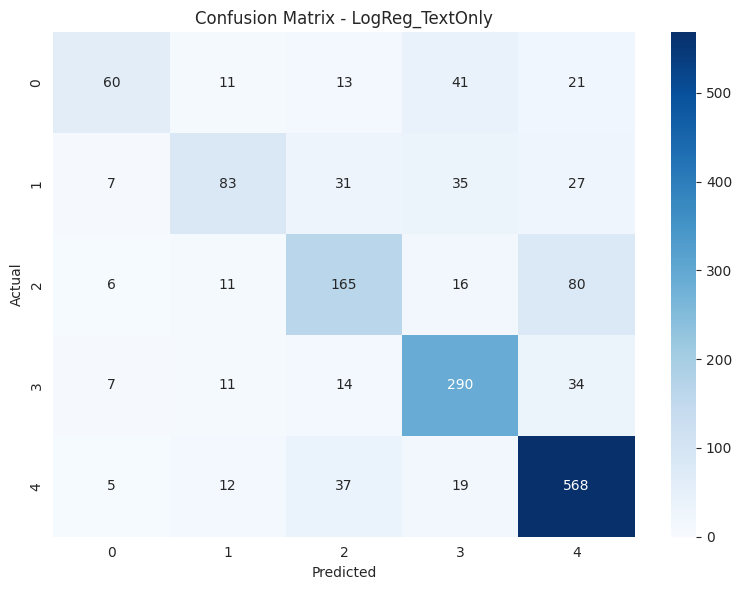


Macro-Averaged AUC: 0.8768
95% CI for Macro-Averaged AUC: [0.8631, 0.8897]


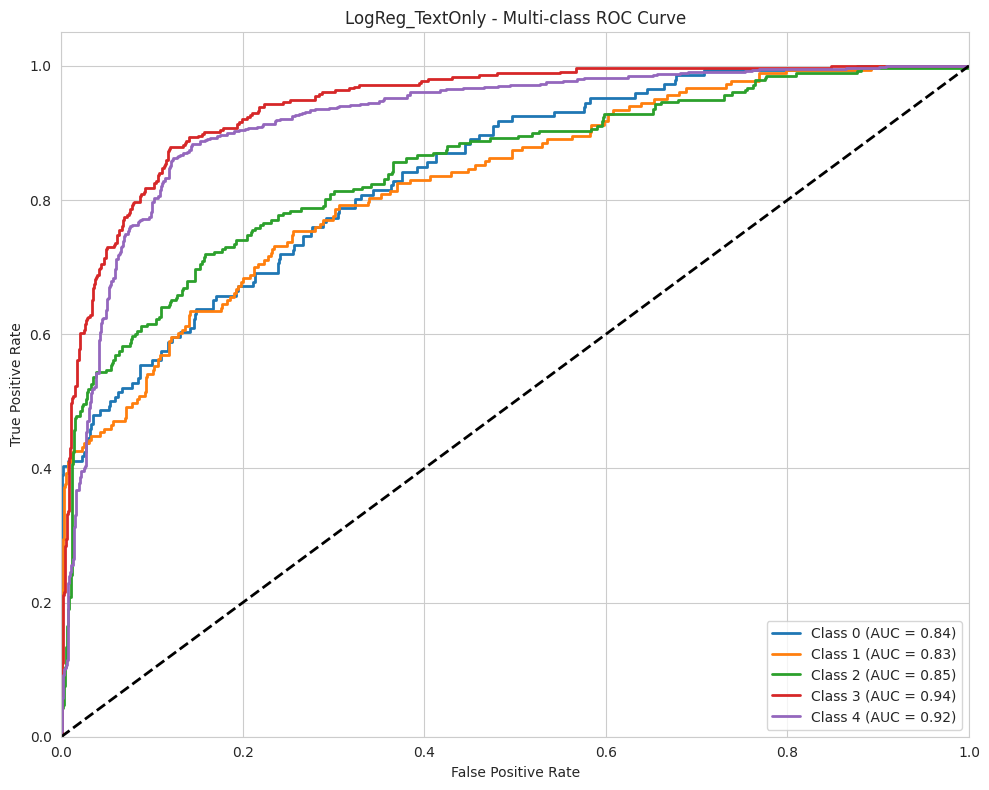

In [ ]:
y_pred_logreg, y_proba_logreg = predict_logreg(
    model=logreg_text,
    X_test_text=X_test_tfidf,
    X_test_extra=None,
)

evaluate_ml_multiclass(
    model=logreg_text,
    X_test=X_test_tfidf,
    y_test=y_test_ml,
    model_name="LogReg_TextOnly",
    # save_dir=str(FIG_DIR),   # or None
)


Top 20 drugName:
drugName
Levonorgestrel                        4930
Etonogestrel                          4421
Ethinyl estradiol / norethindrone     3753
Nexplanon                             2892
Ethinyl estradiol / norgestimate      2790
Ethinyl estradiol / levonorgestrel    2503
Phentermine                           2085
Sertraline                            1868
Escitalopram                          1747
Mirena                                1673
Implanon                              1506
Gabapentin                            1415
Bupropion                             1369
Miconazole                            1344
Venlafaxine                           1338
Citalopram                            1308
Medroxyprogesterone                   1308
Duloxetine                            1256
Lexapro                               1250
Bupropion / naltrexone                1249
Name: count, dtype: int64


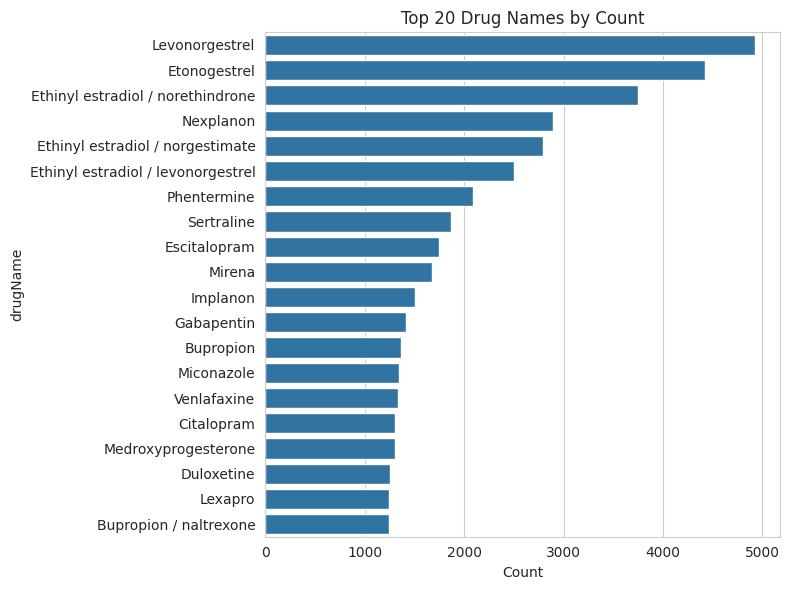


Proportion of reviews covered by top 20 drugs: 0.19531486122671032


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# Raw counts
drug_counts = df_drugs["drugName"].value_counts(dropna=False)
print("\nTop 20 drugName:")
print(drug_counts.head(20))

# Plot top 20 drug names
top_n = 20
top_drugs = drug_counts.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(
    y=top_drugs.index,
    x=top_drugs.values,
    orient="h"
)
plt.title(f"Top {top_n} Drug Names by Count")
plt.xlabel("Count")
plt.ylabel("drugName")
plt.tight_layout()
plt.show()

# Long-tail sense
print("\nProportion of reviews covered by top 20 drugs:",
      top_drugs.sum() / len(df_drugs))


Top 20 condition:
condition
Birth Control                38436
Depression                   12164
Pain                          8245
Anxiety                       7812
Acne                          7435
Bipolar Disorde               5604
Insomnia                      4904
Weight Loss                   4857
Obesity                       4757
ADHD                          4509
Diabetes, Type 2              3362
Emergency Contraception       3290
High Blood Pressure           3104
Vaginal Yeast Infection       3085
Abnormal Uterine Bleeding     2744
Bowel Preparation             2498
Smoking Cessation             2440
ibromyalgia                   2370
Migraine                      2277
Anxiety and Stress            2236
Name: count, dtype: int64


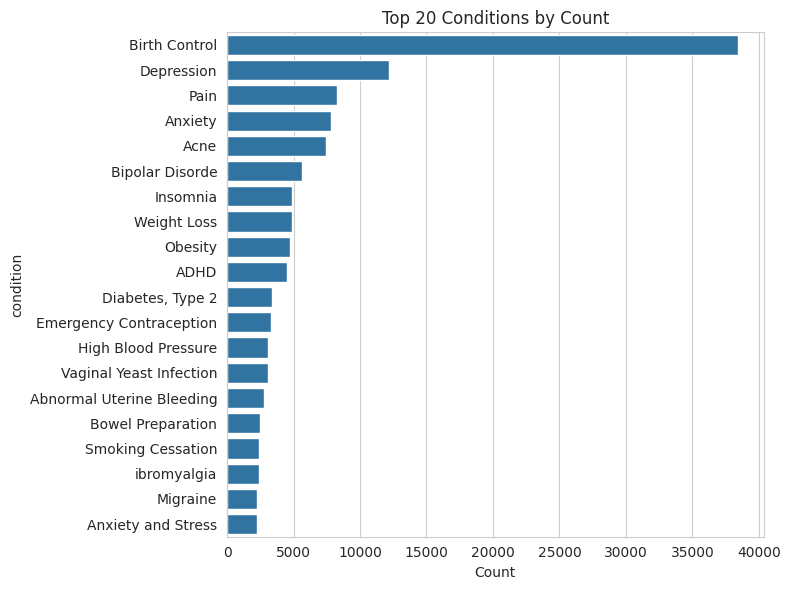


Proportion of reviews covered by top 20 conditions: 0.5864746609133138


In [ ]:
condition_counts = df_drugs["condition"].value_counts(dropna=False)
print("\nTop 20 condition:")
print(condition_counts.head(20))

top_n = 20
top_conditions = condition_counts.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(
    y=top_conditions.index,
    x=top_conditions.values,
    orient="h"
)
plt.title(f"Top {top_n} Conditions by Count")
plt.xlabel("Count")
plt.ylabel("condition")
plt.tight_layout()
plt.show()

print("\nProportion of reviews covered by top 20 conditions:",
      top_conditions.sum() / len(df_drugs))

In [ ]:
# 1. Clean the condition column a bit
df_drugs["condition_clean"] = (
    df_drugs["condition"]
    .astype(str)
    .str.strip()
)

# 2. Frequency table (most useful view)
cond_counts = df_drugs["condition_clean"].value_counts()

print("Number of unique conditions:", cond_counts.shape[0])
print("\n=== Conditions sorted by frequency ===")
print(cond_counts)

Number of unique conditions: 917

=== Conditions sorted by frequency ===
condition_clean
Birth Control                                   38436
Depression                                      12164
Pain                                             8245
Anxiety                                          7812
Acne                                             7435
                                                ...  
Short Stature                                       1
Hypercalcemia                                       1
62</span> users found this comment helpful.         1
92</span> users found this comment helpful.         1
105</span> users found this comment helpful.        1
Name: count, Length: 917, dtype: int64


In [ ]:
print("\n=== Conditions sorted alphabetically ===")
for cond in sorted(df_drugs["condition_clean"].dropna().unique()):
    print(cond)


=== Conditions sorted alphabetically ===
0</span> users found this comment helpful.
100</span> users found this comment helpful.
105</span> users found this comment helpful.
10</span> users found this comment helpful.
110</span> users found this comment helpful.
11</span> users found this comment helpful.
121</span> users found this comment helpful.
123</span> users found this comment helpful.
12</span> users found this comment helpful.
135</span> users found this comment helpful.
13</span> users found this comment helpful.
142</span> users found this comment helpful.
145</span> users found this comment helpful.
146</span> users found this comment helpful.
14</span> users found this comment helpful.
15</span> users found this comment helpful.
16</span> users found this comment helpful.
17</span> users found this comment helpful.
18</span> users found this comment helpful.
19</span> users found this comment helpful.
1</span> users found this comment helpful.
20</span> users found this 

In [ ]:
print(cond_counts.head(50))  # top 50 by count

condition_clean
Birth Control                  38436
Depression                     12164
Pain                            8245
Anxiety                         7812
Acne                            7435
Bipolar Disorde                 5604
Insomnia                        4904
Weight Loss                     4857
Obesity                         4757
ADHD                            4509
Diabetes, Type 2                3362
Emergency Contraception         3290
High Blood Pressure             3104
Vaginal Yeast Infection         3085
Abnormal Uterine Bleeding       2744
Bowel Preparation               2498
Smoking Cessation               2440
ibromyalgia                     2370
Migraine                        2277
Anxiety and Stress              2236
Major Depressive Disorde        2131
Constipation                    2120
Chronic Pain                    1940
Panic Disorde                   1932
Migraine Prevention             1867
Urinary Tract Infection         1747
Muscle Spasm          

In [ ]:
# Remove the display limit
pd.set_option("display.max_rows", None)

cond_counts = df_drugs["condition_clean"].value_counts()

# By frequency (what you already saw, but complete)
print(cond_counts)

# Or alphabetically:
cond_counts_alph = cond_counts.sort_index()
print(cond_counts_alph)

condition_clean
Birth Control                                                          38436
Depression                                                             12164
Pain                                                                    8245
Anxiety                                                                 7812
Acne                                                                    7435
Bipolar Disorde                                                         5604
Insomnia                                                                4904
Weight Loss                                                             4857
Obesity                                                                 4757
ADHD                                                                    4509
Diabetes, Type 2                                                        3362
Emergency Contraception                                                 3290
High Blood Pressure                                         

In [ ]:
mood_conditions = [
    "Depression",
    "Major Depressive Disorde",
    "Persistent Depressive Disorde",
    "Postpartum Depression",
    "Seasonal Affective Disorde",
]

anxiety_conditions = [
    "Anxiety",
    "Anxiety and Stress",
    "Generalized Anxiety Disorde",
    "Panic Disorde",
    "Social Anxiety Disorde",
    "Performance Anxiety",
    "mance Anxiety",   # typo variant
]

mood_anxiety_conditions = mood_conditions + anxiety_conditions

df_mood_anxiety = df_drugs[df_drugs["condition_clean"].isin(mood_anxiety_conditions)].copy()

print(df_mood_anxiety["condition_clean"].value_counts())
print("Total mood+anxiety rows:", len(df_mood_anxiety))

condition_clean
Depression                       12164
Anxiety                           7812
Anxiety and Stress                2236
Major Depressive Disorde          2131
Panic Disorde                     1932
Generalized Anxiety Disorde       1542
Social Anxiety Disorde             522
mance Anxiety                      259
Postpartum Depression              114
Seasonal Affective Disorde          19
Persistent Depressive Disorde       15
Performance Anxiety                  9
Name: count, dtype: int64
Total mood+anxiety rows: 28755


In [ ]:
df_mood_anxiety.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,condition_clean
11,75612,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,9-Mar-17,54,Depression
28,132258,Ativan,Panic Disorde,"""Honestly, I have been taking ativan for 2 yea...",6,1-Jun-15,47,Panic Disorde
31,96233,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,7-May-11,3,Depression
42,173398,Clonazepam,Panic Disorde,"""This medication changed my life. My panic at...",9,1-Apr-08,30,Panic Disorde
44,121333,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,27-Apr-16,3,Depression


In [ ]:
def rating_to_sentiment(r):
    if r <= 2:  return "very_negative"
    if r <= 4:  return "negative"
    if r <= 6:  return "neutral"
    if r <= 8:  return "positive"
    return "very_positive"

df_mood_anxiety["sentiment_5"] = df_mood_anxiety["rating"].apply(rating_to_sentiment)


In [ ]:
df_mood_anxiety.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,condition_clean,sentiment_5
11,75612,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,9-Mar-17,54,Depression,very_positive
28,132258,Ativan,Panic Disorde,"""Honestly, I have been taking ativan for 2 yea...",6,1-Jun-15,47,Panic Disorde,neutral
31,96233,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,7-May-11,3,Depression,positive
42,173398,Clonazepam,Panic Disorde,"""This medication changed my life. My panic at...",9,1-Apr-08,30,Panic Disorde,very_positive
44,121333,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,27-Apr-16,3,Depression,negative


In [ ]:
import os

out_dir = "./data"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "df_mood_anxiety.csv")
df_mood_anxiety.to_csv(out_path, index=False)

print("Saved to:", out_path)

Saved to: ./data/df_mood_anxiety.csv


In [ ]:
targets = {
"Birth Control": 9192,
"Pain": 1978,
"Acne": 1784,
"Weight Loss": 1165,
"Obesity": 1141,
"Diabetes, Type 2": 807,
"Emergency Contraception": 789,
"High Blood Pressure": 745,
"Vaginal Yeast Infection": 740,
"Abnormal Uterine Bleeding": 658,
"Bowel Preparation": 599,
"Smoking Cessation": 585,
"ibromyalgia": 568,
"Migraine": 546,
"Constipation": 508,
"Chronic Pain": 465,
"Migraine Prevention": 447,
"Urinary Tract Infection": 418,
"Muscle Spasm": 391,
"Osteoarthritis": 389,
"Opiate Dependence": 354,
"Erectile Dysfunction": 351,
"Irritable Bowel Syndrome": 321,
"Allergic Rhinitis": 317,
"Rheumatoid Arthritis": 315,
"Bacterial Infection": 300,
"Cough": 293,
"Sinusitis": 269,
"Nausea/Vomiting": 243,
"GERD": 232,
"Overactive Bladde": 220,
"Hyperhidrosis": 220,
"Multiple Sclerosis": 219,
"Hepatitis C": 216,
"HIV Infection": 196,
"High Cholesterol": 196,
"Back Pain": 194,
"Restless Legs Syndrome": 193,
"Psoriasis": 191
}

# Optional: exclude junk HTML conditions if they exist in your raw pull
df2 = df_drugs.copy()
df2 = df2[df2["condition_clean"].isin(targets.keys())]

# stratified sample
df_generalized = (
    df2.groupby("condition_clean", group_keys=False)
       .apply(lambda g: g.sample(n=targets[g.name], random_state=42))
       .reset_index(drop=True)
)

len(df_generalized)  # should be 28755

/tmp/ipython-input-3509255745.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=targets[g.name], random_state=42))


28755

In [ ]:
df_generalized["sentiment_5"] = df_generalized["rating"].apply(rating_to_sentiment)

In [ ]:
import os

out_dir = "./data"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "df_generalized.csv")
df_generalized.to_csv(out_path, index=False)

print("Saved to:", out_path)

Saved to: ./data/df_generalized.csv
